# 1.환경 준비

- 기본 **라이브러리**와 대상 **데이터**를 가져와 이후 과정을 준비한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [2]:
# admission_simple.csv
path = 'data/admission_simple.csv'
df = pd.read_csv(path)

df

,GRE,TOEFL,RANK,SOP,LOR,GPA,RESEARCH,ADMIT
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,1
496,337,117,5,5.0,5.0,9.87,1,1
497,330,120,5,4.5,5.0,9.56,1,1
498,312,103,4,4.0,5.0,8.43,0,0


# 2.데이터 이해

- 분석할 데이터를 **충분히 이해**할 수 있도록 다양한 **탐색** 과정을 수행한다.

In [3]:
df.head()

,GRE,TOEFL,RANK,SOP,LOR,GPA,RESEARCH,ADMIT
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0


In [4]:
df.tail()

,GRE,TOEFL,RANK,SOP,LOR,GPA,RESEARCH,ADMIT
495,332,108,5,4.5,4.0,9.02,1,1
496,337,117,5,5.0,5.0,9.87,1,1
497,330,120,5,4.5,5.0,9.56,1,1
498,312,103,4,4.0,5.0,8.43,0,0
499,327,113,4,4.5,4.5,9.04,0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GRE       500 non-null    int64  
 1   TOEFL     500 non-null    int64  
 2   RANK      500 non-null    int64  
 3   SOP       500 non-null    float64
 4   LOR       500 non-null    float64
 5   GPA       500 non-null    float64
 6   RESEARCH  500 non-null    int64  
 7   ADMIT     500 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 31.4 KB


In [6]:
df.describe()

,GRE,TOEFL,RANK,SOP,LOR,GPA,RESEARCH,ADMIT
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.436000
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.496384
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.000000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.000000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.000000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,1.000000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,1.000000


In [7]:
df.corr()

,GRE,TOEFL,RANK,SOP,LOR,GPA,RESEARCH,ADMIT
GRE,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398,0.701671
TOEFL,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012,0.680503
RANK,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047,0.618367
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116,0.606876
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526,0.536527
GPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311,0.752196
RESEARCH,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000,0.503104
ADMIT,0.701671,0.680503,0.618367,0.606876,0.536527,0.752196,0.503104,1.000000


# 3.데이터 전처리

- **전처리** 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비한다.

**3) x, y 분리**

- 우선 target 변수를 명확히 지정한다.
- target을 제외한 나머지 변수들 데이터는 X로 선언한다.
- target 변수 데이터는 y로 선언한다.
- 이 결과로 만들어진 X는 데이터프레임, y는 시리즈가 된다.
- 이후 모든 작업은 X, y를 대상으로 진행한다.

In [8]:
target = 'ADMIT'
X = df.drop(target, axis=1)
y = df[target]

**4) 학습용, 평가용 데이터 분리**

- 학습용, 평가용 데이터를 적절한 비율로 분리한다.
- 반복 실행 시 동일한 결과를 얻기 위해 random_state 옵션을 지정한다.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=1)

# 4.모델링

- 본격적으로 모델을 **선언**하고 **학습**하고 **평가**하는 과정을 진행한다.
- 우선 **회귀** 문제인지 **분류** 문제인지 명확히 구분한다.

- 회귀 문제 인가? 분류 문제인가?
- 회귀인지 분류인지에 따라 사용할 알고리즘과 평가 방법이 달라진다.
- 다음 알고리즘 사용
    - 알고리즘: KNeighborsClassifier

In [10]:
# 1. 불러오기
from sklearn.neighbors import KNeighborsClassifier

In [11]:
# 2. 선언하기
model = KNeighborsClassifier()

In [ ]:
# 3. 학습하기
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [13]:
# 4. 예측하기
y_pred = model.predict(X_test)

# 5.분류 성능 평가

- 다양한 성능 지표로 분류 모델 성능 평가

**1) Confusion Matrix**

In [15]:
# 모듈 불러오기
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[173  30]
 [ 25 122]]


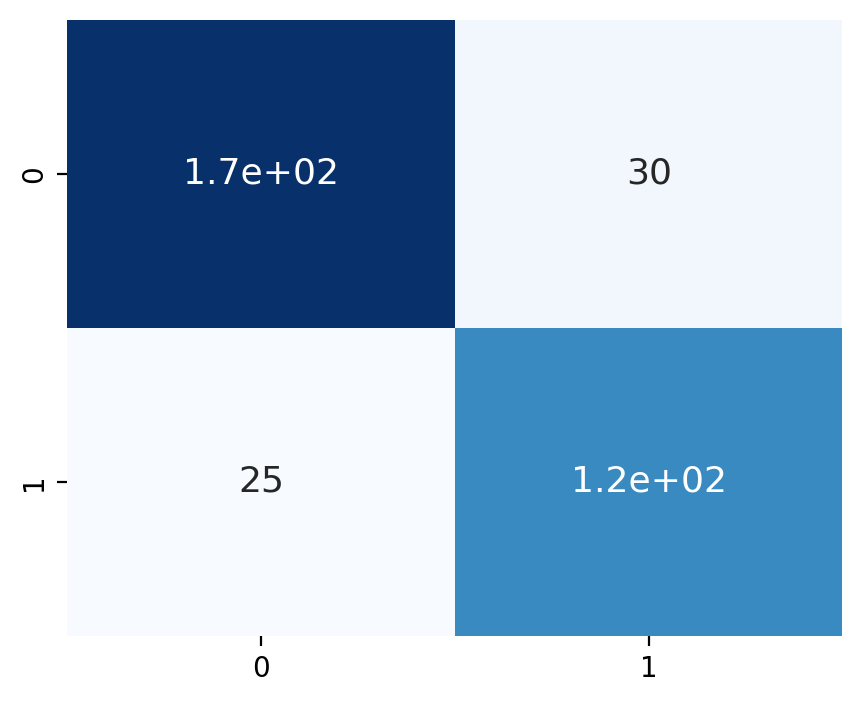

In [18]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            cbar=False,
            cmap='Blues',
            annot_kws={'size': 13})
plt.show()

**2) Accuracy**

$$\large Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$

In [20]:
from sklearn.metrics import accuracy_score

# 성능평가
print('Accuracy : ', accuracy_score(y_test, y_pred))

Accuracy :  0.8428571428571429


**3) Precision**

$$\large Precision = \frac{TP}{TP+FP}$$

In [ ]:
# 양성이라고 예측한 것 중에 진짜 양성이 몇%?
from sklearn.metrics import precision_score

print('Precision :', precision_score(y_test, y_pred))
print('Precision :', precision_score(y_test, y_pred, average=None))
# [0: 에 대한 pre, 1: 에 대한 pre]
print('Precision :', precision_score(y_test, y_pred, average='macro'))
# 각 클래스의 precision을 평균 내서 계산(산술 평균)
print('Precision :', precision_score(y_test, y_pred, average='weighted'))
# 각 클래스별로 가중치를 적용한 평균 -> 샘플 수가 많은 클래스에 더 높은 가중치를 부여

Precision : 0.8026315789473685
Precision : [0.87373737 0.80263158]
Precision : 0.8381844763423711
Precision : 0.8438729399255714


- average 옵션 값: binary(default), micro, macro, weighted, samples, None

**4) Recall**

$$\large Recall = \frac{TP}{TP+FN}$$

In [26]:
# 실제 양성을 양성이라고 예측 비율
from sklearn.metrics import recall_score

print('Recall_score :', recall_score(y_test, y_pred))

Recall_score : 0.8299319727891157


**5) F1-Score**

$$\large F1 = \frac{2\times Precision\times Recall}{Precision+Recall}$$

In [28]:
from sklearn.metrics import f1_score

print('F1_score :', f1_score(y_test, y_pred))

F1_score : 0.8160535117056856


**6) Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
# macro avg : 클래스 샘플 개수를 고려하지 않고 계산
# weighted avg : 샘플 개수에 따라 가중 평균 계산

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       203
           1       0.80      0.83      0.82       147

    accuracy                           0.84       350
   macro avg       0.84      0.84      0.84       350
weighted avg       0.84      0.84      0.84       350

